# Домашнє завдання: класифікація товарів Fashion MNIST за допомогою Keras

У цьому ноутбуці створюється власна **повнозв'язна нейронна мережа** для класифікації зображень одягу з датасету **Fashion MNIST**.

Важливо: у цьому завданні **не використовуються згорткові шари**, оскільки CNN — це тема наступного завдання.

Мета: отримати точність на тестових даних приблизно **0.88–0.89**.

Використано:
- `Flatten` для перетворення зображення 28×28 у вектор;
- кілька `Dense`-шарів;
- `BatchNormalization`;
- `Dropout`;
- `Adam`;
- `EarlyStopping` та `ReduceLROnPlateau`.


In [1]:
# Імпорт бібліотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

from sklearn.metrics import classification_report, confusion_matrix

print('TensorFlow version:', tf.__version__)
print('GPU available:', len(tf.config.list_physical_devices('GPU')) > 0)

TensorFlow version: 2.20.0
GPU available: False


In [2]:
# Фіксуємо seed для відтворюваності результатів
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

## 1. Завантаження та підготовка даних

In [3]:
# Завантажуємо Fashion MNIST
(x_train_full, y_train_full), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

print('Train full:', x_train_full.shape, y_train_full.shape)
print('Test:', x_test.shape, y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train full: (60000, 28, 28) (60000,)
Test: (10000, 28, 28) (10000,)


In [4]:
# Нормалізація пікселів у діапазон [0, 1]
x_train_full = x_train_full.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Для повнозв'язної мережі НЕ додаємо канал і НЕ використовуємо Conv2D.
# Зображення залишаємо у форматі (28, 28), а шар Flatten сам перетворить їх у вектор.

# Виділяємо validation set з тренувальної вибірки
validation_size = 5000
x_valid = x_train_full[:validation_size]
y_valid = y_train_full[:validation_size]
x_train = x_train_full[validation_size:]
y_train = y_train_full[validation_size:]

print('Train:', x_train.shape, y_train.shape)
print('Validation:', x_valid.shape, y_valid.shape)
print('Test:', x_test.shape, y_test.shape)


Train: (55000, 28, 28) (55000,)
Validation: (5000, 28, 28) (5000,)
Test: (10000, 28, 28) (10000,)


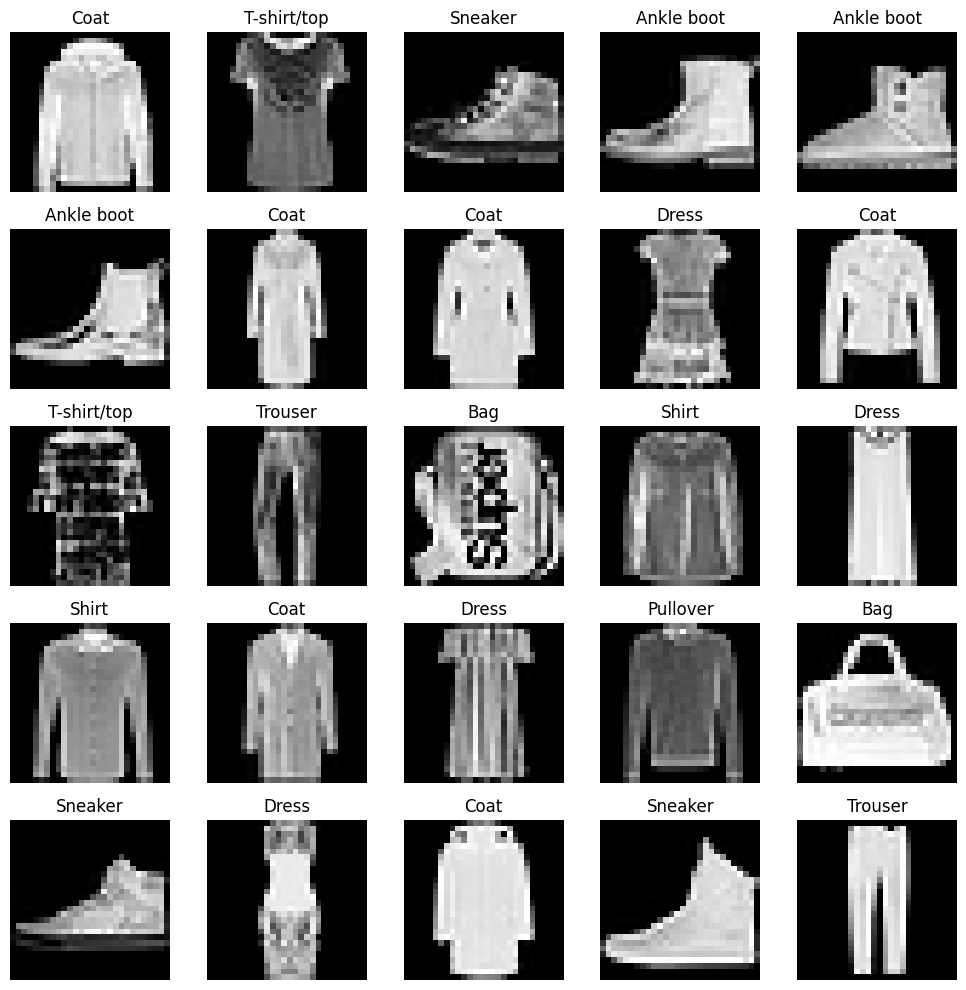

In [5]:
# Візуалізація прикладів із датасету
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.imshow(x_train[i].squeeze(), cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.tight_layout()
plt.show()

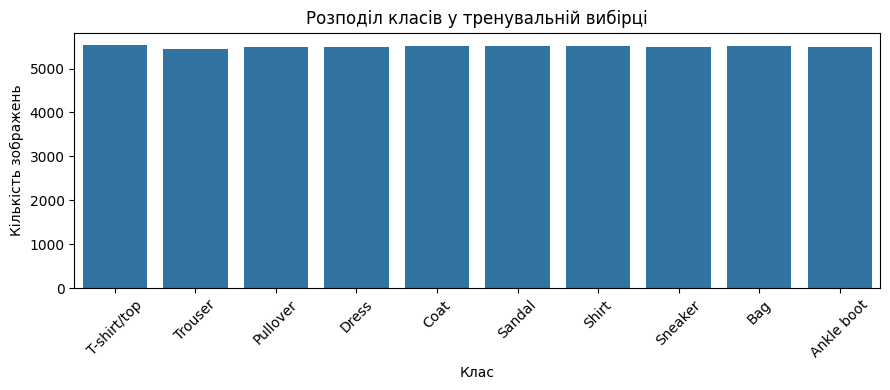

In [6]:
# Перевіримо баланс класів у тренувальній вибірці
plt.figure(figsize=(9, 4))
sns.countplot(x=y_train)
plt.title('Розподіл класів у тренувальній вибірці')
plt.xlabel('Клас')
plt.ylabel('Кількість зображень')
plt.xticks(ticks=range(10), labels=class_names, rotation=45)
plt.tight_layout()
plt.show()

## 2. Побудова архітектури моделі

Обрана архітектура — **повнозв'язна нейронна мережа без згорткових шарів**:

- `Flatten` перетворює зображення 28×28 у вектор із 784 ознак;
- кілька `Dense`-шарів із `relu` вивчають нелінійні залежності;
- `BatchNormalization` стабілізує навчання;
- `Dropout` зменшує перенавчання;
- `softmax` на виході повертає ймовірності 10 класів;
- оптимізатор `Adam`;
- функція втрат `sparse_categorical_crossentropy`, бо мітки класів задані числами від 0 до 9.


In [7]:
def build_model():
    model = keras.Sequential([
        layers.Input(shape=(28, 28)),
        layers.Flatten(),

        layers.Dense(512, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.30),

        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.30),

        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.20),

        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

model = build_model()
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 571,018 (2.18 MB)

 Trainable params: 569,226 (2.17 MB)

 Non-trainable params: 1,792 (7.00 KB)

## 3. Навчання моделі

Для підвищення якості використовуємо callback-и:

- `EarlyStopping` — зупиняє навчання, якщо validation loss перестав покращуватися;
- `ReduceLROnPlateau` — зменшує learning rate при застої якості;
- `ModelCheckpoint` — зберігає найкращу модель за validation accuracy.

Очікувана точність повнозв'язної моделі на тесті: приблизно **0.88–0.89**.


In [8]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=8,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath='best_fashion_mnist_dense_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

history = model.fit(
    x_train,
    y_train,
    validation_data=(x_valid, y_valid),
    epochs=50,
    batch_size=128,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/50
427/430 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7536 - loss: 0.7203
Epoch 1: val_accuracy improved from None to 0.83420, saving model to best_fashion_mnist_dense_model.keras

Epoch 1: finished saving model to best_fashion_mnist_dense_model.keras
430/430 ━━━━━━━━━━━━━━━━━━━━ 12s 21ms/step - accuracy: 0.8042 - loss: 0.5541 - val_accuracy: 0.8342 - val_loss: 0.4429 - learning_rate: 0.0010
Epoch 2/50
430/430 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8393 - loss: 0.4429
Epoch 2: val_accuracy improved from 0.83420 to 0.86980, saving model to best_fashion_mnist_dense_model.keras

Epoch 2: finished saving model to best_fashion_mnist_dense_model.keras
430/430 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.8445 - loss: 0.4287 - val_accuracy: 0.8698 - val_loss: 0.3644 - learning_rate: 0.0010
Epoch 3/50
430/430 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8545 - loss: 0.3993
Epoch 3: val_accuracy did not improve from 0.86980
430/430 ━━━━━━━━━━━━━━━━━━━━ 9s 17ms/step - 

## 4. Графіки навчання

In [9]:
history_df = pd.DataFrame(history.history)
history_df.head()

,accuracy,loss,val_accuracy,val_loss,learning_rate
0,0.804236,0.554087,0.8342,0.442928,0.001
1,0.844545,0.428655,0.8698,0.364432,0.001
2,0.855836,0.395057,0.8670,0.368622,0.001
3,0.859782,0.378205,0.8718,0.359632,0.001
4,0.868145,0.361424,0.8714,0.363561,0.001


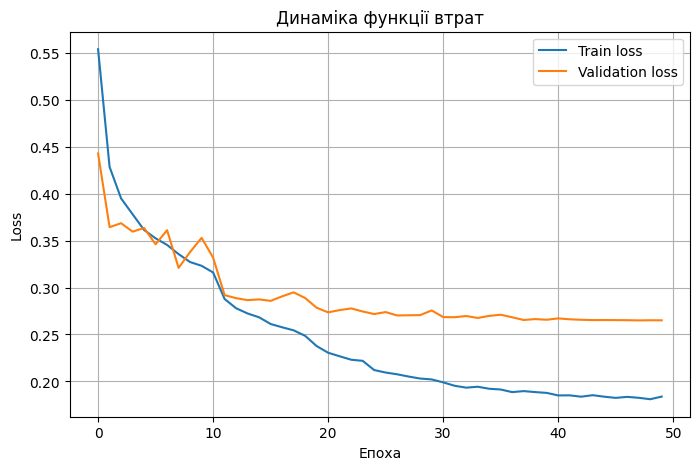

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Validation loss')
plt.title('Динаміка функції втрат')
plt.xlabel('Епоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

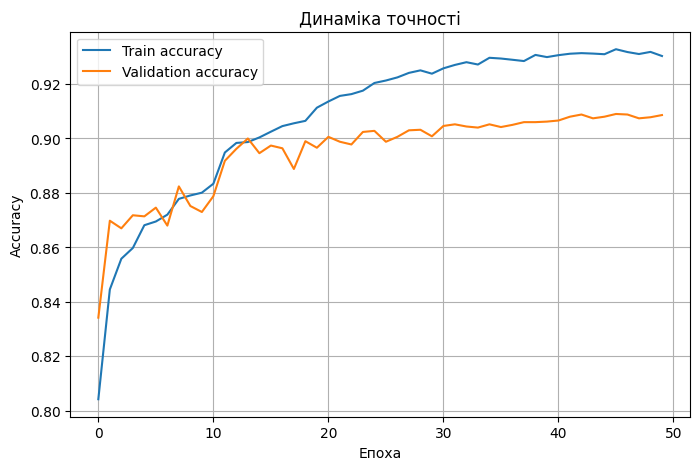

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Train accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.title('Динаміка точності')
plt.xlabel('Епоха')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

## 5. Оцінка моделі на тестових даних

In [12]:
# Завантажуємо найкращу модель, якщо файл був створений callback-ом
try:
    model = keras.models.load_model('best_fashion_mnist_dense_model.keras')
    print('Завантажено найкращу модель з файлу best_fashion_mnist_dense_model.keras')
except Exception as e:
    print('Використовується поточна модель:', e)

test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f'Втрати на тестових даних: {test_loss:.4f}')
print(f'Точність на тестових даних: {test_accuracy:.4f}')


Завантажено найкращу модель з файлу best_fashion_mnist_dense_model.keras
Втрати на тестових даних: 0.3059
Точність на тестових даних: 0.8981


In [13]:
# Прогнозування класів для тестової вибірки
y_pred_proba = model.predict(x_test, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

print('Перші 10 справжніх класів:     ', y_test[:10])
print('Перші 10 передбачених класів: ', y_pred[:10])

Перші 10 справжніх класів:      [9 2 1 1 6 1 4 6 5 7]
Перші 10 передбачених класів:  [9 2 1 1 6 1 4 6 5 7]


## 6. Матриця помилок

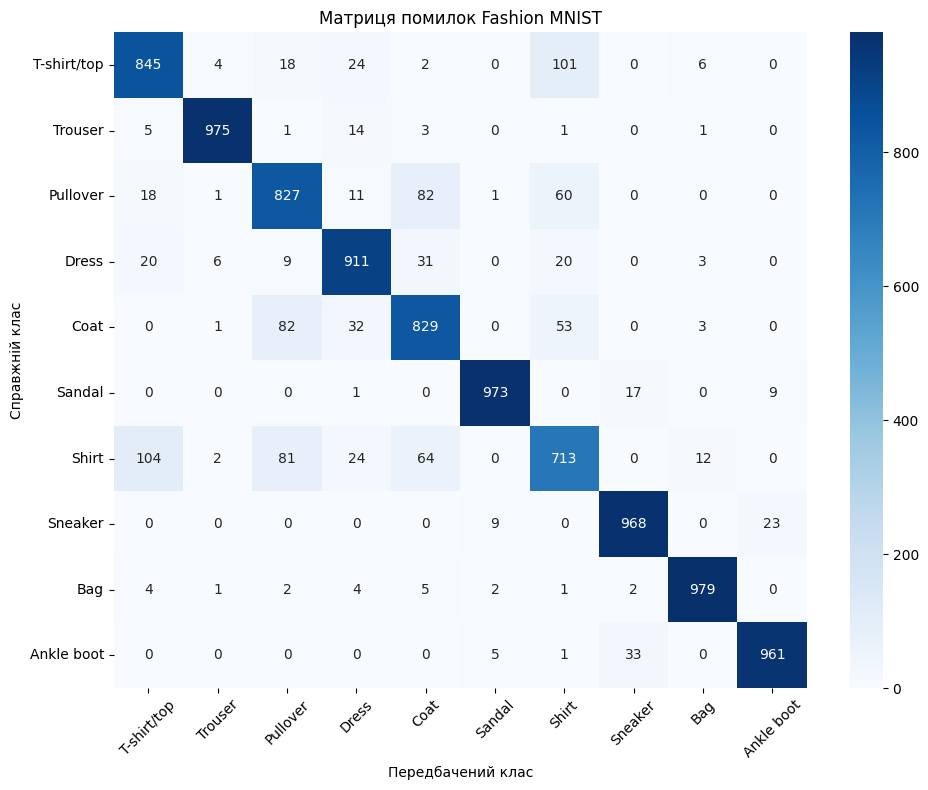

In [14]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title('Матриця помилок Fashion MNIST')
plt.xlabel('Передбачений клас')
plt.ylabel('Справжній клас')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 7. Метрики якості для кожного класу

Використовуємо `classification_report` зі `sklearn.metrics`.

In [15]:
report = classification_report(
    y_test,
    y_pred,
    target_names=class_names,
    digits=4
)
print(report)

              precision    recall  f1-score   support

 T-shirt/top     0.8484    0.8450    0.8467      1000
     Trouser     0.9848    0.9750    0.9799      1000
    Pullover     0.8108    0.8270    0.8188      1000
       Dress     0.8923    0.9110    0.9015      1000
        Coat     0.8159    0.8290    0.8224      1000
      Sandal     0.9828    0.9730    0.9779      1000
       Shirt     0.7505    0.7130    0.7313      1000
     Sneaker     0.9490    0.9680    0.9584      1000
         Bag     0.9751    0.9790    0.9770      1000
  Ankle boot     0.9678    0.9610    0.9644      1000

    accuracy                         0.8981     10000
   macro avg     0.8977    0.8981    0.8978     10000
weighted avg     0.8977    0.8981    0.8978     10000



In [16]:
# Табличне представлення classification_report
report_dict = classification_report(
    y_test,
    y_pred,
    target_names=class_names,
    digits=4,
    output_dict=True
)

report_df = pd.DataFrame(report_dict).transpose()
report_df

,precision,recall,f1-score,support
T-shirt/top,0.848394,0.8450,0.846693,1000.0000
Trouser,0.984848,0.9750,0.979899,1000.0000
Pullover,0.810784,0.8270,0.818812,1000.0000
Dress,0.892262,0.9110,0.901534,1000.0000
Coat,0.815945,0.8290,0.822421,1000.0000
Sandal,0.982828,0.9730,0.977889,1000.0000
Shirt,0.750526,0.7130,0.731282,1000.0000
Sneaker,0.949020,0.9680,0.958416,1000.0000
Bag,0.975100,0.9790,0.977046,1000.0000
Ankle boot,0.967774,0.9610,0.964375,1000.0000


## 8. Приклади правильних та помилкових передбачень

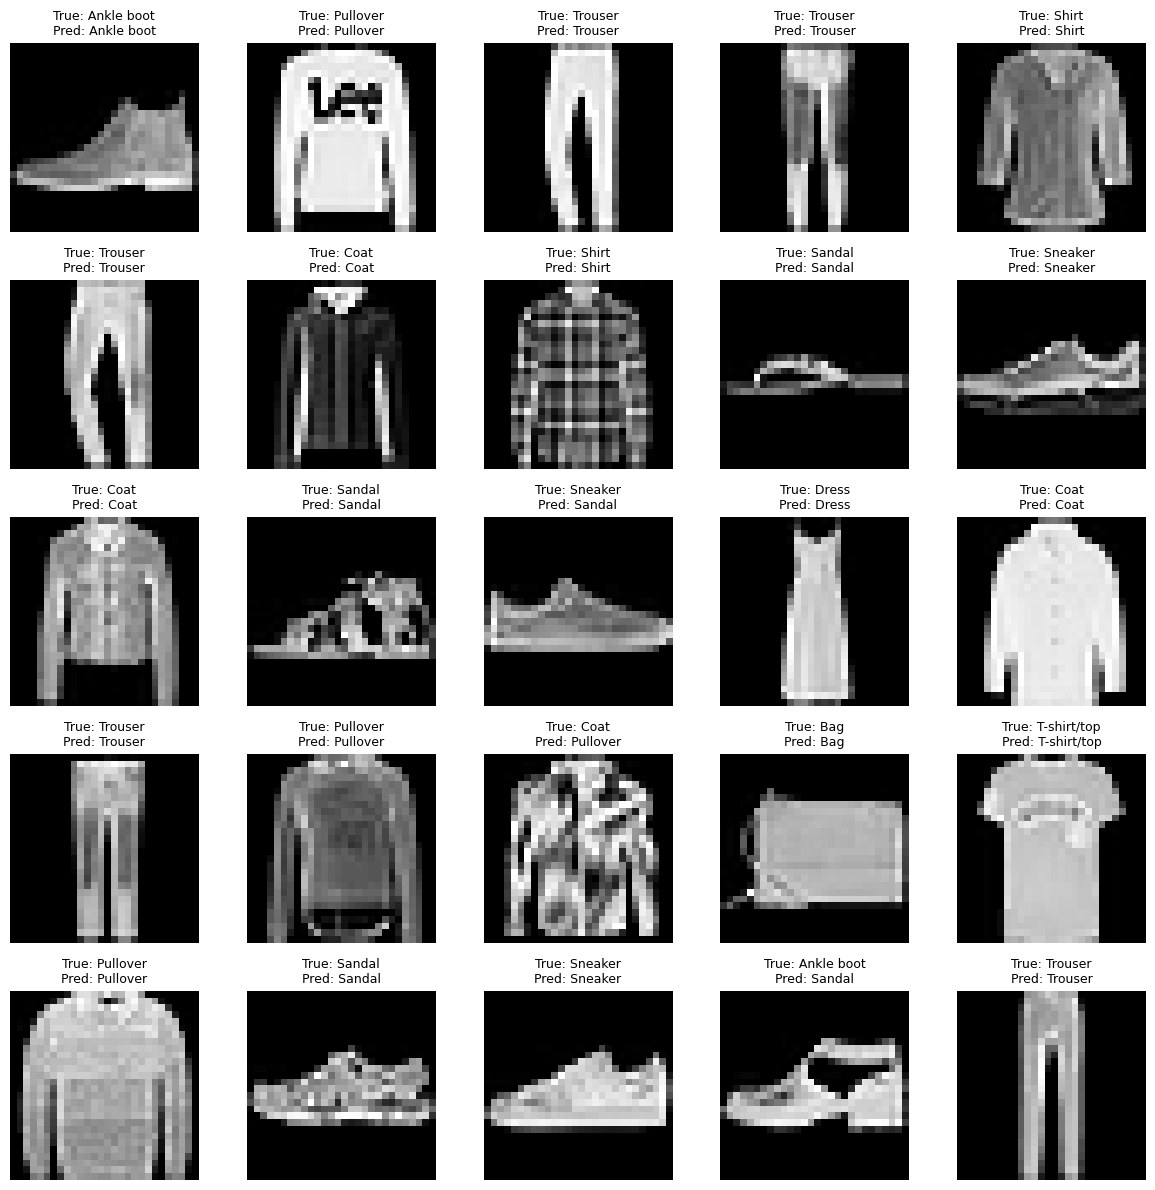

In [17]:
# Візуалізація кількох передбачень моделі
plt.figure(figsize=(12, 12))
for i in range(25):
    plt.subplot(5, 5, i + 1)

    plt.imshow(x_test[i].squeeze(), cmap='gray')

    true_label = class_names[y_test[i]]
    pred_label = class_names[y_pred[i]]

    title = f"True: {true_label}\nPred: {pred_label}"

    plt.title(title, fontsize=9)
    plt.axis('off')

plt.tight_layout()
plt.show()

Кількість помилок: 1019


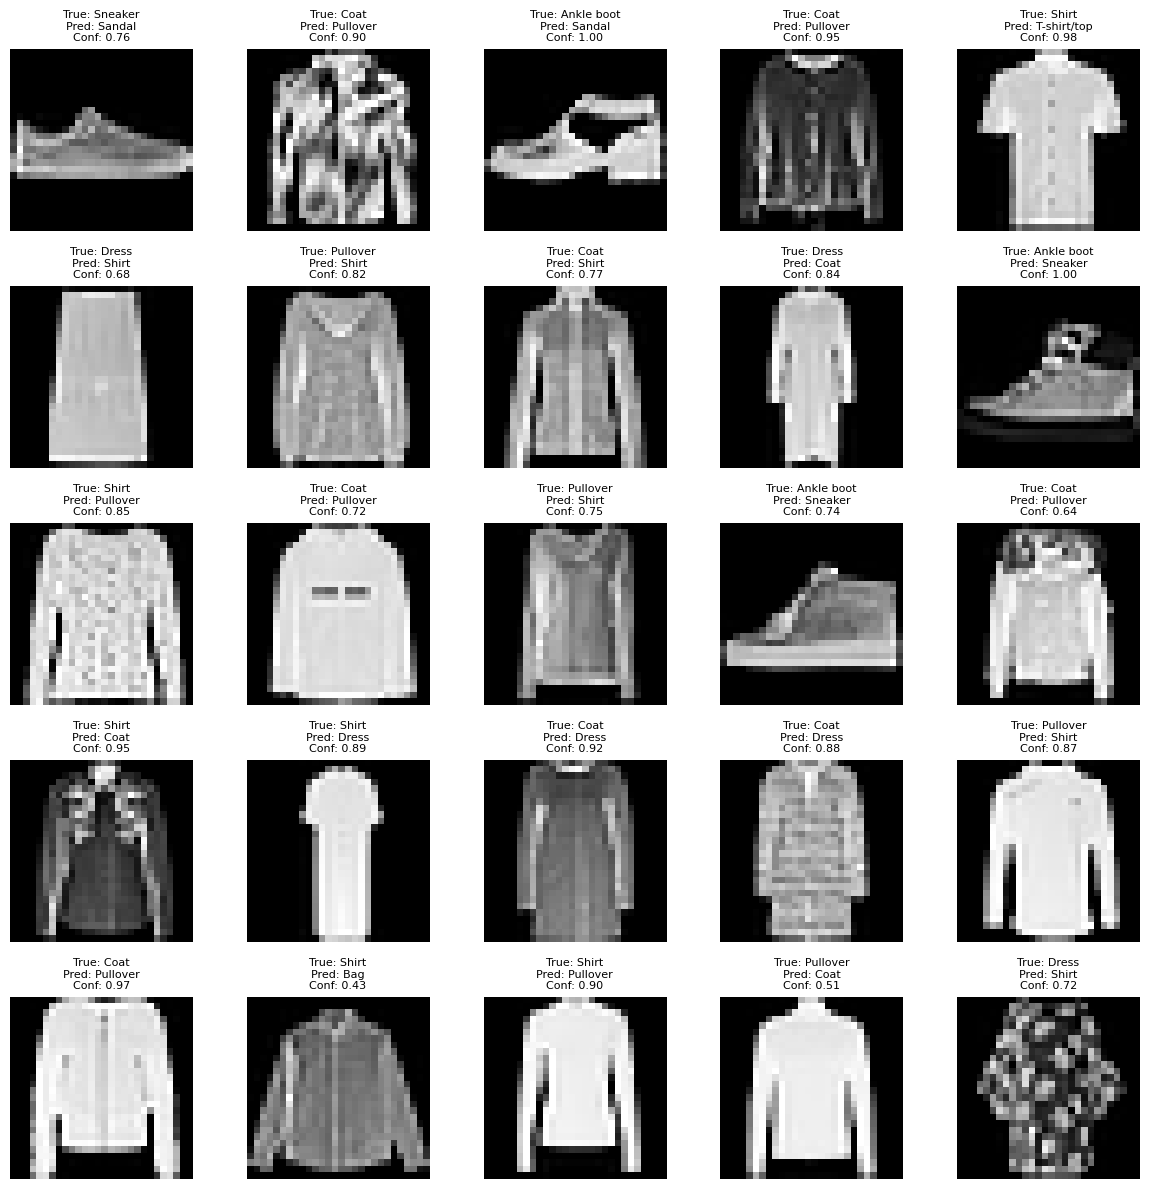

In [18]:
# Помилково класифіковані приклади
wrong_idx = np.where(y_test != y_pred)[0]
print("Кількість помилок:", len(wrong_idx))

plt.figure(figsize=(12, 12))

for i, idx in enumerate(wrong_idx[:25]):
    plt.subplot(5, 5, i + 1)

    plt.imshow(x_test[idx].squeeze(), cmap='gray')

    true_label = class_names[y_test[idx]]
    pred_label = class_names[y_pred[idx]]
    confidence = np.max(y_pred_proba[idx])

    title = (
        f"True: {true_label}\n"
        f"Pred: {pred_label}\n"
        f"Conf: {confidence:.2f}"
    )

    plt.title(title, fontsize=8)

    plt.axis('off')

plt.tight_layout()
plt.show()

## 9. Висновки

1. Для задачі класифікації Fashion MNIST була побудована повнозв'язна нейронна мережа на Keras без використання згорткових шарів.
2. Архітектура містить `Flatten`, кілька `Dense`-шарів, `BatchNormalization` та `Dropout`.
3. Така модель зазвичай показує точність на тестовій вибірці приблизно **0.88–0.89**, що відповідає очікуваному результату для цього завдання.
4. За графіками `loss` та `accuracy` можна оцінити якість навчання: якщо validation loss зростає, а train loss зменшується, це ознака перенавчання.
5. Callback-и `EarlyStopping` і `ReduceLROnPlateau` допомагають стабілізувати навчання та уникати зайвих епох.
6. Найскладнішими для класифікації залишаються схожі класи: `Shirt`, `T-shirt/top`, `Pullover` і `Coat`.
7. `classification_report` показує precision, recall та f1-score для кожного класу, тому дає детальнішу оцінку моделі, ніж лише загальна accuracy.
